In [1]:
import pandas as pd

df = pd.read_csv("data/processed/preprocessed_dataset.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (250000, 50)


,Vehicle_ID,Make_and_Model,Vehicle_Type,Year_of_Manufacture,Route_Info,Weather_Conditions,Road_Conditions,Communication_Interface,Telematics_Gateway,Edge_Device_Class,...,OHI,CMES,UER,Predictive_Score,Pre_Event_Record,Data_Split,FL_Client_ID,Partition_Type,Local_Epochs_Per_Round,Communication_Rounds
0,1,1,4,2016.263210,1,4,4,1,0,2,...,1.533067,1.253629,60.544697,0.164941,1,1,1,0,2,200
1,2,0,2,2016.101678,1,5,3,2,0,3,...,1.400740,3.807979,30.947927,0.150258,1,0,1,0,2,200
2,3,3,3,2011.648228,1,4,0,2,0,1,...,2.470239,0.000000,75.771246,0.182817,1,1,2,0,2,200
3,4,4,0,2020.812445,0,5,1,0,2,0,...,0.926741,0.732097,46.057219,0.153179,1,1,3,0,2,200
4,5,4,1,2022.314726,2,4,2,2,2,3,...,0.248311,5.567024,3.530082,0.223569,1,1,4,0,2,200


In [2]:
corr = df.corr(numeric_only=True)

target_corr = (
    corr["Maintenance_Required"]
    .sort_values(ascending=False)
)

target_corr

Maintenance_Required             1.000000
Maintenance_Severity_ID          0.661985
Predictive_Score                 0.619522
Impact_on_Efficiency             0.579116
Fuel_Consumption                 0.575331
Days_Since_Last_Maintenance      0.573490
TPI                              0.565937
CMES                             0.564911
Vibration_Levels                 0.559709
Engine_Temperature               0.545675
Downtime_Maintenance             0.536472
ADS                              0.526262
Historical_Maintenance_Cost      0.521478
Maintenance_Cost                 0.520993
CAN_Message_Rate_Hz              0.516599
Sensor_Packet_Loss_Rate          0.509179
Anomalies_Detected               0.481607
PCR                              0.478094
MBF                              0.471971
Diagnostic_Trouble_Code_Count    0.467034
Failure_History                  0.438540
OHI                              0.242705
FL_Client_ID                     0.184418
Actual_Load                      0

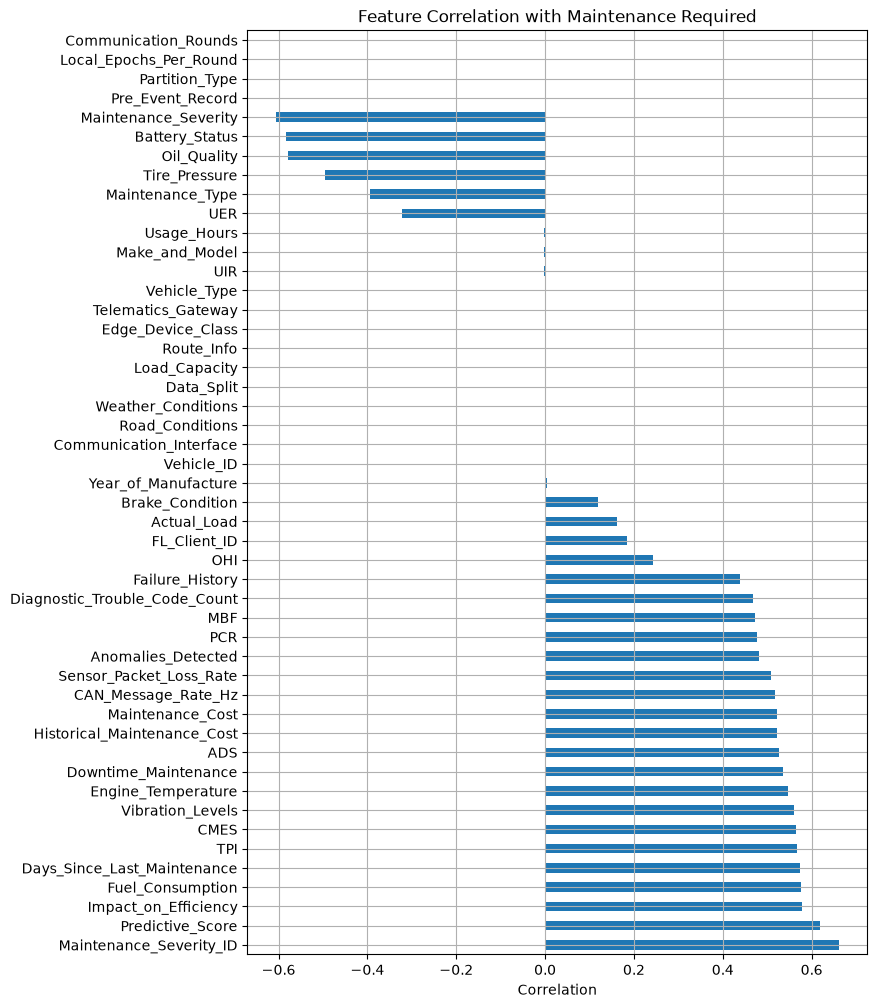

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,12))

target_corr.drop("Maintenance_Required").plot(kind="barh")

plt.title("Feature Correlation with Maintenance Required")
plt.xlabel("Correlation")
plt.grid(True)

plt.show()

In [4]:
suspected_leakage = pd.DataFrame({
    "Feature":[

        "Vehicle_ID",
        "Last_Maintenance_Date",

        "Predictive_Score",
        "PCR",
        "UIR",
        "TPI",
        "MBF",
        "ADS",
        "OHI",
        "CMES",
        "UER",

        "Maintenance_Cost",
        "Downtime_Maintenance",
        "Maintenance_Type",
        "Maintenance_Severity",
        "Maintenance_Severity_ID",

        "FL_Client_ID",
        "Partition_Type",
        "Local_Epochs_Per_Round",
        "Communication_Rounds",
        "Data_Split",

        "Pre_Event_Record"

    ],

    "Reason":[

        "Unique identifier",
        "Date information",

        "Derived prediction score",
        "Engineered metric",
        "Engineered metric",
        "Engineered metric",
        "Engineered metric",
        "Engineered metric",
        "Engineered metric",
        "Engineered metric",
        "Engineered metric",

        "Known after maintenance",
        "Known after maintenance",
        "Assigned after maintenance",
        "Target-related information",
        "Encoded target",

        "Federated Learning metadata",
        "Federated Learning metadata",
        "Federated Learning metadata",
        "Federated Learning metadata",
        "Dataset split information",

        "Experimental flag"
    ]
})

suspected_leakage

,Feature,Reason
0,Vehicle_ID,Unique identifier
1,Last_Maintenance_Date,Date information
2,Predictive_Score,Derived prediction score
3,PCR,Engineered metric
4,UIR,Engineered metric
5,TPI,Engineered metric
6,MBF,Engineered metric
7,ADS,Engineered metric
8,OHI,Engineered metric
9,CMES,Engineered metric


In [5]:
remove_features = suspected_leakage["Feature"].tolist()

df_clean = df.drop(columns=remove_features)

print("Original Shape :", df.shape)
print("After Removal :", df_clean.shape)

Original Shape : (250000, 50)
After Removal : (250000, 28)


In [6]:
print(df_clean.columns.tolist())

['Make_and_Model', 'Vehicle_Type', 'Year_of_Manufacture', 'Route_Info', 'Weather_Conditions', 'Road_Conditions', 'Communication_Interface', 'Telematics_Gateway', 'Edge_Device_Class', 'Usage_Hours', 'Load_Capacity', 'Actual_Load', 'Engine_Temperature', 'Tire_Pressure', 'Fuel_Consumption', 'Battery_Status', 'Vibration_Levels', 'Oil_Quality', 'Failure_History', 'Anomalies_Detected', 'Diagnostic_Trouble_Code_Count', 'CAN_Message_Rate_Hz', 'Sensor_Packet_Loss_Rate', 'Historical_Maintenance_Cost', 'Impact_on_Efficiency', 'Days_Since_Last_Maintenance', 'Brake_Condition', 'Maintenance_Required']


In [7]:
df_clean.to_csv(
    "data/processed/leakage_free_dataset.csv",
    index=False
)

print("Leakage-free dataset saved successfully!")

Leakage-free dataset saved successfully!
